In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from tqdm import tqdm
from pygam import LinearGAM, s


# helper functions

In [16]:
def analyze_roi_trends(df, roi_metadata, strategy='linear', show_plot=True):
    """
    Analyzes trends of coefficients across age bins.
    Strategies: 'linear', 'quadratic', 'gam'
    """
    model_results = {}
    
    for row in roi_metadata.itertuples():
        roi_id = row.region_label
        roi_name = row.name
        
        # Filter data for this ROI
        region_data = df[df['region_label'] == roi_id].copy().sort_values('mid_age_bin')
        
        # Minimum data points check (GAM needs more points usually)
        min_points = 5 if strategy == 'gam' else 3
        if len(region_data) < min_points:
            continue

        region_data['is_significant'] = region_data['fdr_p'] < 0.05
        X = region_data['mid_age_bin'].values.reshape(-1, 1)
        y = region_data['coef'].values

        # --- MODELING ---
        if strategy == 'linear':
            model = smf.ols('coef ~ mid_age_bin', data=region_data).fit()
            y_pred = model.predict(region_data)
            
        elif strategy == 'quadratic':
            model = smf.ols('coef ~ mid_age_bin + np.power(mid_age_bin, 2)', data=region_data).fit()
            y_pred = model.predict(region_data)
            
        elif strategy == 'gam':
            # LinearGAM with a spline term
            model = LinearGAM(s(0)).fit(X, y)
            y_pred = model.predict(X)
        
        # Store for future clustering
        model_results[roi_name] = {
            'roi_id': roi_id,
            'model': model,
            'y_pred': y_pred, # These predictions are great for clustering "shapes"
            'ages': region_data['mid_age_bin'].values
        }

        # --- PLOTTING ---
        if show_plot:
            plt.figure(figsize=(6, 4))
            palette_colors = {True: "tab:blue", False: "lightgray"}

            # Plot the trend line
            plt.plot(region_data['mid_age_bin'], y_pred, color='red', 
                     linestyle='--', linewidth=1.5, zorder=1, label=f'{strategy.capitalize()} Fit')

            # Plot raw points
            sns.scatterplot(
                data=region_data,
                x='mid_age_bin',
                y='coef',
                hue='is_significant',
                palette=palette_colors,
                s=60,
                zorder=2,
                legend=False
            )
            
            # Optional: Add thin line connecting raw points to show trajectory
            plt.plot(region_data['mid_age_bin'], region_data['coef'], color='gray', alpha=0.3, zorder=0)

            plt.title(f'{strategy.upper()} Trend: Birth Year Coef vs Age\n{roi_name}', fontsize=10)
            plt.xlabel('Median Age of Window')
            plt.ylabel('Birth Year Coefficient')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

    return model_results

# loading files

In [17]:
coef_df = pd.read_csv('/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/coef_df_sliding_wy5_sy1.csv')
birth_year_coef_df = coef_df[(coef_df['variable'] == 'birth_year')]
atlas_csv = pd.read_csv("/home/gaia/Projects/legacy_data/my_master/space-MNI152_atlas-schaefer2018tian2020_res-1mm_den-400_div-7networks_dseg.csv")



# configurations

In [18]:
max_bins = birth_year_coef_df['bin'].unique().size
print("Total amount of bins:", max_bins)

# interesting percentage of significant age bins
interesting_percentage = 0.5

th_of_bins = int(max_bins * interesting_percentage)
print("Treshold of bins to be interesting:",th_of_bins)

Total amount of bins: 52
Treshold of bins to be interesting: 26


## extracting interesting rois (repeat in many age bins)

In [19]:
significant_birth_year_coef_df = birth_year_coef_df[birth_year_coef_df['fdr_p'] < 0.05]

# create a df with ['region_label', number of age_bin significant coefficients]
age_bin_significant_coef_df = significant_birth_year_coef_df.groupby('region_label').size().reset_index(name='num_significant_age_bins')

print(f"amount of rois with more than {max_bins*interesting_percentage} age bins (sorted decending): {age_bin_significant_coef_df[age_bin_significant_coef_df['num_significant_age_bins'] >= max_bins*interesting_percentage].shape[0]}")

# merge with atlas_csv to get network information
# rename index to region_label in atlas_csv
atlas_csv = atlas_csv.rename(columns={'index': 'region_label'})
age_bin_significant_coef_df = age_bin_significant_coef_df.merge(atlas_csv[['region_label', 'name', 'network', 'component', 'hemisphere']], on='region_label', how='left')

top_sig_rois = age_bin_significant_coef_df[age_bin_significant_coef_df['num_significant_age_bins'] >= max_bins*interesting_percentage].sort_values(by='num_significant_age_bins', ascending=False)[['region_label', 'name','num_significant_age_bins', 'network', 'component', 'hemisphere']]

print(f"list of interesting rois: {top_sig_rois}")



amount of rois with more than 26.0 age bins (sorted decending): 64
list of interesting rois:      region_label                                   name  \
411           421                                lAMY-rh   
231           237                  7Networks_RH_SomMot_7   
412           422                                mAMY-rh   
399           409                             THA-VPl-rh   
404           414                              PUT-DA-rh   
..            ...                                    ...   
93             97   7Networks_LH_SalVentAttn_FrOperIns_1   
287           295  7Networks_RH_SalVentAttn_TempOccPar_2   
296           304   7Networks_RH_SalVentAttn_FrOperIns_3   
305           313         7Networks_RH_SalVentAttn_Med_3   
332           340               7Networks_RH_Cont_PFCv_1   

     num_significant_age_bins                       network  \
411                        44                     subcortex   
231                        41                   somatomotor 

In [20]:
print(top_sig_rois.columns.tolist())

['region_label', 'name', 'num_significant_age_bins', 'network', 'component', 'hemisphere']


## modeling of coefficient along ages

In [21]:
# CONFIGURATION

# coef_df strategy:
# Options: 'fixed', 'sliding_n_subjects', or 'sliding_n_years'
STRATEGY = 'sliding_n_years' 

# Parameters for 'sliding_n_subjects'
window_subjects = 100 
step_subjects = 50

# Parameters for 'sliding_n_years'
window_years = 5
step_years = 1

# Parameters for 'fixed'
bin_size = 5

# roi list
# roi_list = list(range(1, 455))
roi_list = top_sig_rois['region_label'].tolist()
# roi_list = [421]

In [22]:
def extract_median_age(bin_val):
    if pd.isna(bin_val):
        return None
    try:
        # Splits 'W01_Age_20.0-30.0' -> '20.0-30.0' -> [20.0, 30.0]
        age_range = str(bin_val).split('_Age_')[1]
        age_min, age_max = map(float, age_range.split('-'))
        return (age_min + age_max) / 2
    except:
        return None

if STRATEGY == 'fixed':
    birth_year_coef_df['mid_age_bin'] = birth_year_coef_df['bin'].apply(lambda x: x.mid)
elif 'sliding' in STRATEGY:
    birth_year_coef_df['mid_age_bin'] = birth_year_coef_df['bin'].apply(extract_median_age)

# --- 2. ITERATE OVER TOP ROIs DATAFRAME ---
# top_sig_rois has: region_label, name, num_significant_age_bins, etc.





/tmp/ipykernel_9234/2388865857.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  birth_year_coef_df['mid_age_bin'] = birth_year_coef_df['bin'].apply(extract_median_age)


In [23]:
best_birth_year_coef_df = birth_year_coef_df[birth_year_coef_df['region_label'].isin(top_sig_rois['region_label'])]

In [24]:
trend_models = analyze_roi_trends(best_birth_year_coef_df, top_sig_rois, strategy='gam', show_plot=False)

In [25]:
print(trend_models.values())

dict_values([{'roi_id': 421, 'model': LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, terms=s(0) + intercept, tol=0.0001, 
   verbose=False), 'y_pred': array([4.74433592, 4.71138792, 4.67282592, 4.62992081, 4.58566283,
       4.54991959, 4.53427804, 4.54669212, 4.58058378, 4.62574192,
       4.67253256, 4.71362994, 4.7422854 , 4.75408357, 4.75394236,
       4.74911294, 4.74929733, 4.7740007 , 4.845179  , 4.97636659,
       5.14741127, 5.32973923, 5.49583822, 5.62244222, 5.68734673,
       5.67797618, 5.62027041, 5.54979818, 5.49773001, 5.47764364,
       5.49871861, 5.56519456, 5.66155162, 5.76733003, 5.86099983,
       5.91675005, 5.90769954, 5.81215448, 5.62917057, 5.36299084,
       5.03194928, 4.71074363, 4.48816258, 4.43338477, 4.53714873,
       4.77058293, 5.09751879, 5.45259933, 5.76317048, 5.97304785,
       6.09192568, 6.14596791]), 'ages': array([22.5, 23.5, 24.5, 25.5, 26.5, 27.5, 28.5, 29.5, 30.5, 31.5, 32.5,
       33.5, 34.5, 

## clustering rois by their model

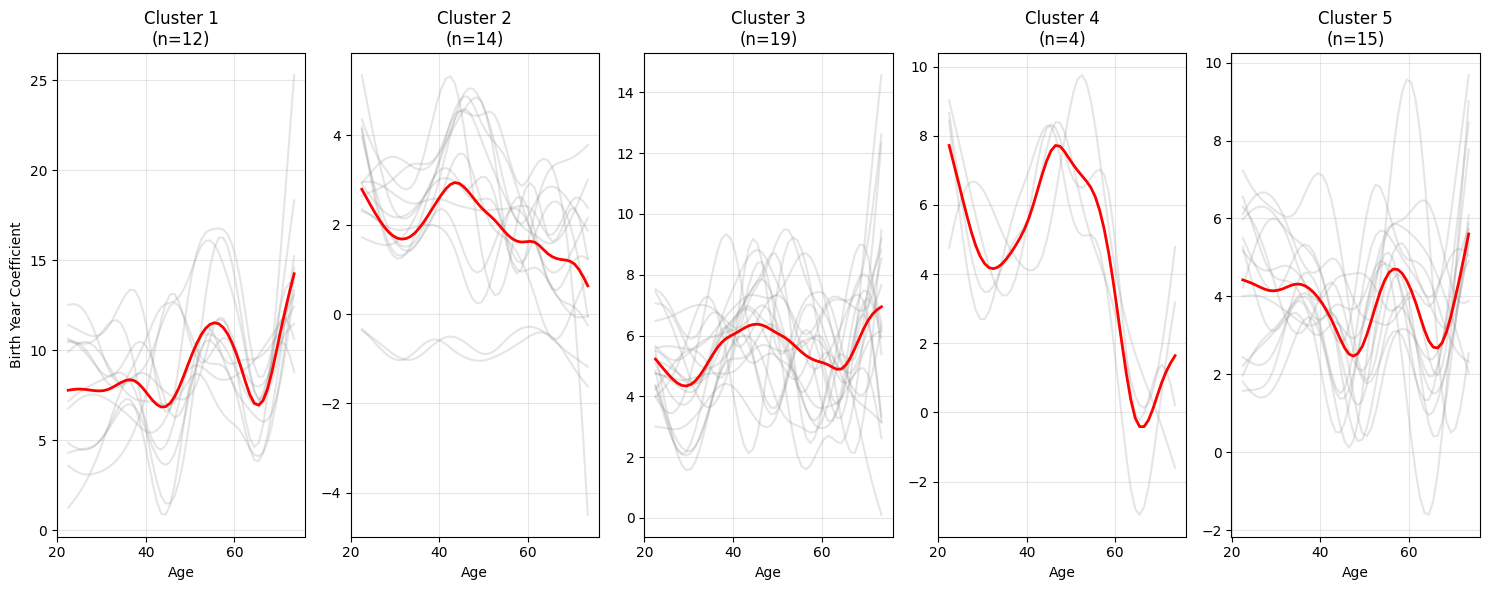


Cluster 3 (n=19):
 - lAMY-rh (Region Label: 421)
 - mAMY-rh (Region Label: 422)
 - PUT-DA-rh (Region Label: 414)
 - mAMY-lh (Region Label: 449)
 - 7Networks_LH_SomMot_8 (Region Label: 39)
 - 7Networks_RH_Default_Temp_5 (Region Label: 371)
 - PUT-VP-lh (Region Label: 442)
 - PUT-DP-lh (Region Label: 443)
 - 7Networks_LH_Default_PFC_12 (Region Label: 177)
 - PUT-DA-lh (Region Label: 441)
 - 7Networks_LH_SomMot_6 (Region Label: 37)
 - PUT-VA-rh (Region Label: 413)
 - 7Networks_RH_SomMot_10 (Region Label: 240)
 - 7Networks_RH_DorsAttn_Post_16 (Region Label: 286)
 - 7Networks_RH_SalVentAttn_TempOccPar_4 (Region Label: 297)
 - 7Networks_RH_DorsAttn_Post_12 (Region Label: 282)
 - 7Networks_LH_SalVentAttn_Med_1 (Region Label: 107)
 - 7Networks_RH_SomMot_23 (Region Label: 253)
 - 7Networks_RH_SalVentAttn_Med_3 (Region Label: 313)

Cluster 1 (n=12):
 - 7Networks_RH_SomMot_7 (Region Label: 237)
 - 7Networks_RH_SomMot_1 (Region Label: 231)
 - 7Networks_RH_SomMot_3 (Region Label: 233)
 - 7Networks

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler

def cluster_existing_models(trend_models, n_clusters=4, use_magnitude=False):
    # 1. Extract the ROI names and the predicted curves
    roi_names = list(trend_models.keys())
    # This creates a matrix of shape (n_rois, 52)
    data_matrix = np.array([trend_models[name]['y_pred'] for name in roi_names])
    
    # 2. Get the age axis from the first entry for plotting
    first_roi = roi_names[0]
    common_ages = trend_models[first_roi]['ages']

    # 3. Handle Magnitude vs Shape
    if use_magnitude:
        clustering_input = data_matrix
        ylabel = "Birth Year Coefficient"
    else:
        # Standardize so each ROI trend has mean=0, std=1
        scaler = StandardScaler()
        clustering_input = scaler.fit_transform(data_matrix.T).T
        ylabel = "Z-Score (Shape Only)"

    # 4. Hierarchical Clustering (Ward's Method)
    Z = linkage(clustering_input, method='ward')
    cluster_labels = fcluster(Z, n_clusters, criterion='maxclust')

    # 5. Visualization
    plt.figure(figsize=(15, 6))
    
    # Plot Clusters
    for c in range(1, n_clusters + 1):
        plt.subplot(1, n_clusters, c)
        indices = [i for i, lbl in enumerate(cluster_labels) if lbl == c]
        
        # Plot individual lines
        for idx in indices:
            plt.plot(common_ages, clustering_input[idx], color='gray', alpha=0.2)
        
        # Plot cluster mean
        plt.plot(common_ages, np.mean(clustering_input[indices], axis=0), 
                 color='red', linewidth=2)
        
        plt.title(f"Cluster {c}\n(n={len(indices)})")
        plt.xlabel("Age")
        if c == 1: plt.ylabel(ylabel)
        plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Return a simple mapping for your next steps
    return {name: cluster_labels[i] for i, name in enumerate(roi_names)}, Z

# Run it
cluster_assignments, linkage_matrix = cluster_existing_models(trend_models, n_clusters=5, use_magnitude=True)

# print a list of rois in each cluster - region_label and name
from collections import defaultdict
clusters = defaultdict(list)
for roi_name, cluster_id in cluster_assignments.items():
    roi_info = top_sig_rois[top_sig_rois['name'] == roi_name][['region_label', 'name']].iloc[0]
    clusters[cluster_id].append(roi_info)

# print the clusters info in a readable way
for cluster_id, rois in clusters.items():
    print(f"\nCluster {cluster_id} (n={len(rois)}):")
    for roi in rois:
        print(f" - {roi['name']} (Region Label: {roi['region_label']})")

Mapping 64 ROIs to their respective clusters...


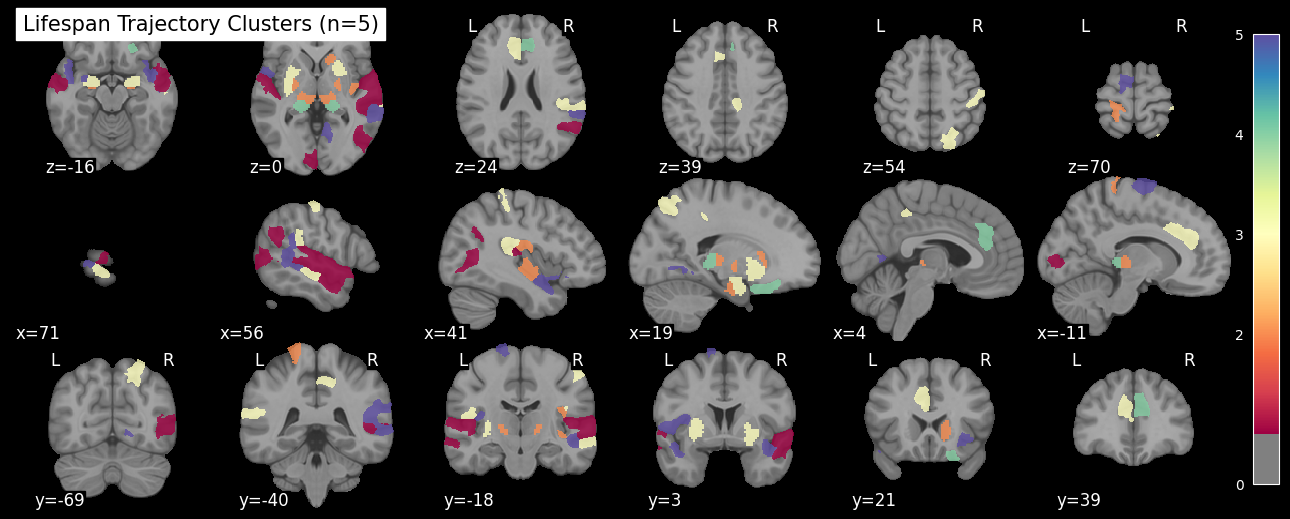

In [27]:
import numpy as np
import nibabel as nib
from nilearn import plotting
from nilearn.image import new_img_like
from nilearn.datasets import load_mni152_template

label_to_cluster = {}
for name, cluster_id in cluster_assignments.items():
    # Cross-reference with top_sig_rois to get the numeric label
    label = top_sig_rois.loc[top_sig_rois['name'] == name, 'region_label'].values[0]
    label_to_cluster[label] = cluster_id

# Count unique clusters for the title
unique_cluster_count = len(set(cluster_assignments.values()))

# --- 2. Load Your Atlas ---
atlas_file_path = '/media/storage/MATLAB_atlases-20250612T134418Z-1-001/MATLAB_atlases/schaefer2018tian2020_400_7.nii'
atlas_img = nib.load(atlas_file_path)
atlas_labels = atlas_img.get_fdata()

# --- 3. Create the Cluster Brain Map ---
# Initialize map with zeros
cluster_map_data = np.zeros_like(atlas_labels, dtype=float)

# Map each label to its assigned cluster ID
print(f"Mapping {len(label_to_cluster)} ROIs to their respective clusters...")
for label, cluster_id in label_to_cluster.items():
    cluster_map_data[atlas_labels == label] = cluster_id

# Create NIfTI image
cluster_img = new_img_like(atlas_img, cluster_map_data)

# --- 4. Plotting ---
bg_img = load_mni152_template()

# Removed the invalid view_type and kept it clean for ROI visualization
plotting.plot_roi(
    roi_img=cluster_img,
    bg_img=bg_img,
    title=f"Lifespan Trajectory Clusters (n={unique_cluster_count})",
    cmap='Spectral', 
    display_mode='mosaic',
    cut_coords=(6, 6, 6),
    colorbar=True,
    alpha=0.8  # Slight transparency helps see the background anatomy
)

plotting.show()